In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

from tqdm.notebook import tqdm
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, Conv2D, Concatenate, Conv2DTranspose

In [8]:
img_w = 128
img_h = 128
img_c = 3
img_shape = (img_w, img_h, img_c)

epoch_num = 5
learning_rate = 0.0001
buffer_size = 1000
batch_size = 16

In [9]:
# segmwntation용 데이터(이미지+정답 마스크)
df_str = "oxford_iiit_pet"
df, info = tfds.load(name=df_str, with_info=True)

In [10]:
#정답 마스크 - 픽셀마다 0(배경), 1(고양이), 2(강아지)
def preprocess_image(ds):
    img = tf.image.resize(ds['image'],(img_w,img_h))
    img = tf.cast(img,tf.float32)/255.0

    # 마스크 크기를 통일 nearest(가까운 값으로 복사)
    # 리사이즈를 하면서 마스크도 리사이즈가 되는데, 마스크 크기를 변경하지만, 클래스값은 바꾸면 안된다
    mask = tf.image.resize(ds['segmentation_mask'],(img_w,img_h),method='nearest')
    mask = tf.cast(mask,tf.int32)
    mask = mask-1

    return img,mask

In [11]:
train_ds = df['train'].map(preprocess_image).shuffle(buffer_size)\
    .batch(batch_size).prefetch(tf.data.AUTOTUNE)

test = df['test'].map(preprocess_image).batch(batch_size)\
    .prefetch(tf.data.AUTOTUNE)

In [12]:
# VGG16 - ImageNet로 학습된 상대

base_model = VGG16(input_shape = img_shape,include_top = False, weights='imagenet')

In [13]:
# CNN은 층마다 보는게 다름
# block1_conv2, block2_conv2: 얕은 층(색,선)
# block3_conv3, block4_conv3: 중간 층(패턴)
# block5_conv3: 깊은 층(물체 형태)

f_model = tf.keras.Model(
    inputs=[base_model.input],
    outputs=[base_model.get_layer(name='block5_conv3').output,
             base_model.get_layer(name='block4_conv3').output,
             base_model.get_layer(name='block3_conv3').output,
             base_model.get_layer(name='block2_conv2').output,
             base_model.get_layer(name='block1_conv2').output,])

### U-Net 모델 정의

In [14]:
test_ds = df['test'].map(preprocess_image).batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [17]:
# VGG16으로 이미지를 작게 줄이며 특징을 뽑고,
# Decoder를 다시 키우면서 위치정보를 복원하는 U-Net모델
inputs = Input(shape=img_shape)

# 숫자가 작아질수록 위치 정보는 떨어지고, 의미 정보는 높아진다
out_8,out_16, out_32 , out_64 , out_128 = f_model(inputs)

# 8에서 16으로 이미지 크기 키우기
x = Conv2DTranspose(512,3,strides=2,padding='same')(out_8)
x = Concatenate()([x,out_16])
x = Conv2D(512,3,padding='same',activation='relu')(x)
x = Conv2D(512,3,padding='same',activation='relu')(x)

# 16에서 32으로 이미지 크기 키우기
x = Conv2DTranspose(256,3,strides=2,padding='same')(x)
x = Concatenate()([x,out_32])
x = Conv2D(256,3,padding='same',activation='relu')(x)
x = Conv2D(256,3,padding='same',activation='relu')(x)

# 32에서 64으로 이미지 크기 키우기
x = Conv2DTranspose(128,3,strides=2,padding='same')(x)
x = Concatenate()([x,out_64])
x = Conv2D(128,3,padding='same',activation='relu')(x)
x = Conv2D(128,3,padding='same',activation='relu')(x)

# 64에서 128으로 이미지 크기 키우기
x = Conv2DTranspose(64,3,strides=2,padding='same')(x)
x = Concatenate()([x,out_128])
x = Conv2D(64,3,padding='same',activation='relu')(x)
x = Conv2D(64,3,padding='same',activation='relu')(x)

outputs = Conv2D(3,1,activation='softmax')(x)

unet_model = tf.keras.Model(inputs=inputs,outputs = outputs)

In [20]:
loss_f = tf.losses.SparseCategoricalCrossentropy()
opt = tf.optimizers.Adam(learning_rate)
unet_model.compile(optimizer = opt , loss = loss_f, metrics=['accuracy'])
unet_model.fit(train_ds,epochs=epoch_num)

Epoch 1/5
230/230 [==============================] - 41s 118ms/step - loss: 0.4927 - accuracy: 0.8143
Epoch 2/5
230/230 [==============================] - 29s 123ms/step - loss: 0.2759 - accuracy: 0.8947
Epoch 3/5
230/230 [==============================] - 29s 123ms/step - loss: 0.2306 - accuracy: 0.9106
Epoch 4/5
230/230 [==============================] - 29s 125ms/step - loss: 0.2112 - accuracy: 0.9172
Epoch 5/5
230/230 [==============================] - 29s 126ms/step - loss: 0.1829 - accuracy: 0.9266


1/1 [==============================] - 0s 32ms/step


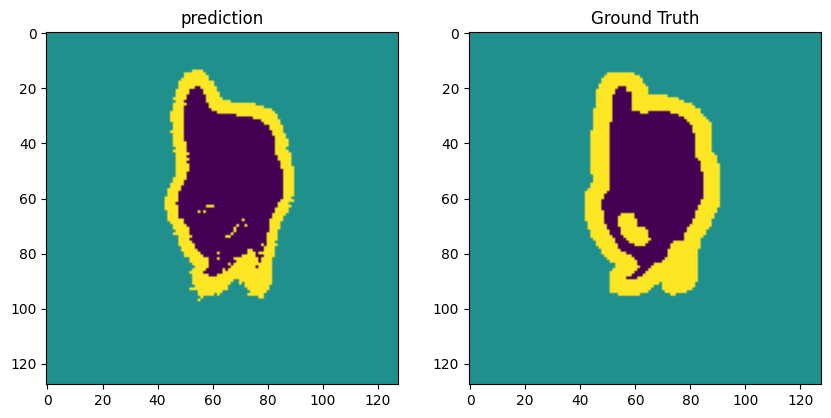

In [24]:
img_batch,mask_batch = next(iter(test_ds))

pred = unet_model.predict(img_batch)

pred_img = np.argmax(pred[0],axis=-1)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('prediction')
plt.imshow(pred_img)

plt.subplot(1,2,2)
plt.title('Ground Truth')
plt.imshow(mask_batch[0])
plt.show()